# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

## Setup and load data
Add the project root to the import path, load the TXT dataset, and split into train/test for modeling.

In [2]:
from pathlib import Path
import sys
import pandas as pd

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

illnesses = [["MDD", "0.001"], ["ADHD", "0.001"], ["ASD", "0.001"], ["OCD", "0.001"], ["SCZ", "0.0001"], ["BIP", "0.001"]]

illness_to_ID = {
    "MDD": 0,
    "ADHD": 1,
    "ASD": 2,
    "OCD": 3,
    "SCZ": 4,
    "BIP": 5
}

df_illnesses = {}

for illness, clumping in illnesses:
    data_path = Path(f"../../data/tmpDATA-Leon/donnees_MRI_{illness}_only_variants_clumping_p_thr_{clumping}all.txt")
    df_illnesses[illness] = load_txt(data_path)

    #rename Z_scores columns to just Z_scores 
    df_illnesses[illness] = df_illnesses[illness].rename(columns={col: "Z_scores" for col in df_illnesses[illness].columns if col.startswith("Z_scores")})

# add column of specific illness for one hot encoding for illness classification
for illness, df in df_illnesses.items():
    df[illness] =  1

# fill missing illness columns with 0s for one hot encoding for illness classification
for illness, df in df_illnesses.items():
    for other_illness in illness_to_ID.keys():
        if other_illness != illness and other_illness not in df.columns:
            df[other_illness] = 0

# combine all dataframes into one
df = pd.concat(df_illnesses.values(), ignore_index=True)

df.info()


#X_train, y_train, X_test, y_test = preprocess(df=df_mdd, target=f"Z_scores_{type}", testsize = 0.2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20428 entries, 0 to 20427
Columns: 1018 entries, Mean_intensity_3rd-Ventricle_whole-brain to BIP
dtypes: float64(1011), int64(6), object(1)
memory usage: 158.7+ MB


In [3]:
# count number of samples for each illness
for illness in illness_to_ID.keys():
    count = df[df[illness] == 1].shape[0]
    print(f"{illness}: {count} samples")

MDD: 4045 samples
ADHD: 3213 samples
ASD: 2890 samples
OCD: 2027 samples
SCZ: 3533 samples
BIP: 4720 samples


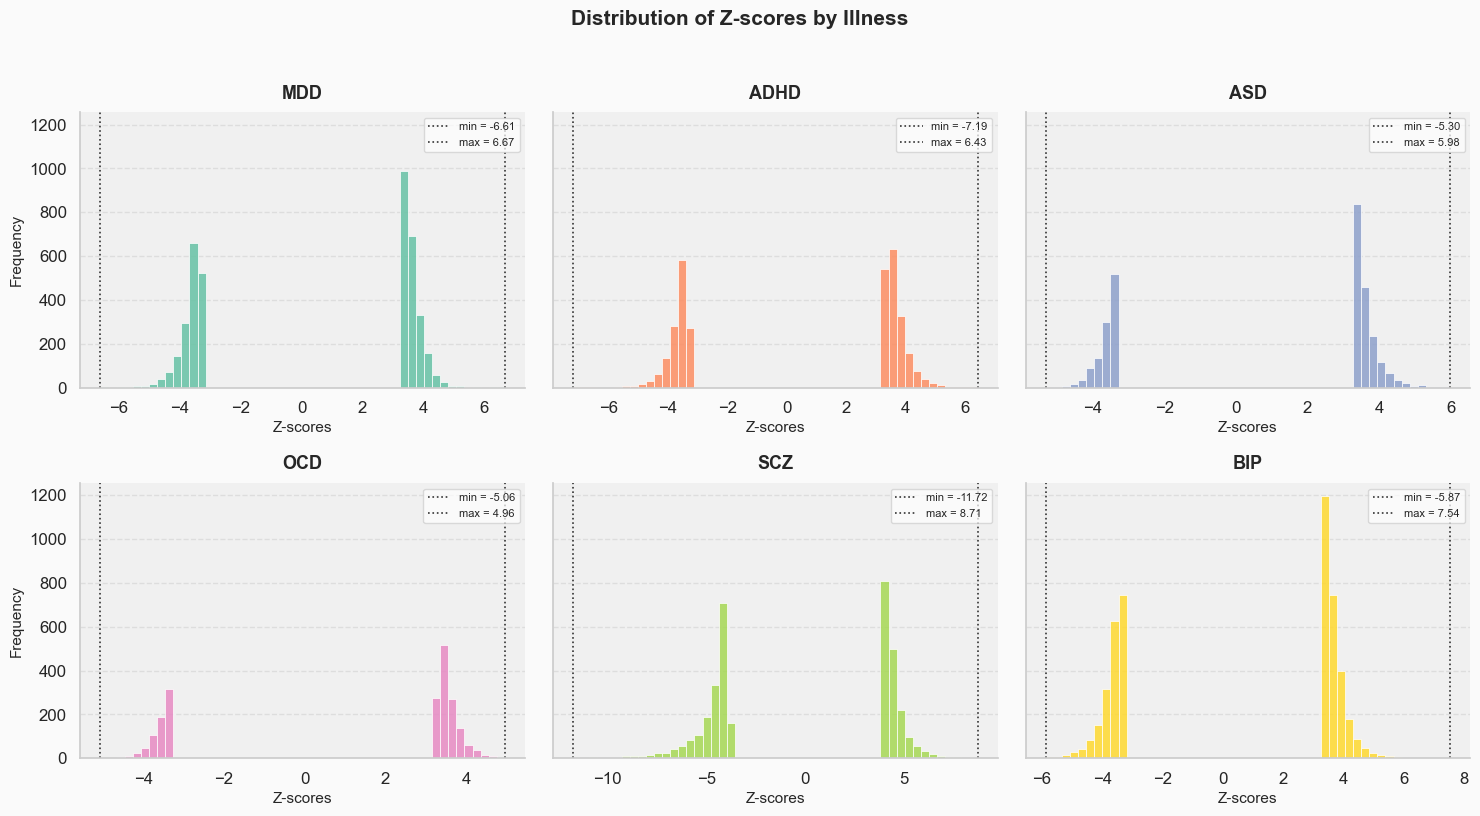

In [4]:
# plot distribution of Z_scores for each illness
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
illness_colors = sns.color_palette("Set2", len(illness_to_ID))

n_illnesses = len(illness_to_ID)
ncols = 3
nrows = math.ceil(n_illnesses / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()

for i, illness in enumerate(illness_to_ID.keys()):
    ax = axes[i]
    df_illness = df[df[illness] == 1]
    z = df_illness["Z_scores"]
    ax.hist(z, bins=50, color=illness_colors[i],
            edgecolor="white", linewidth=0.6, alpha=0.85)
    # dotted lines for min and max
    ax.axvline(z.min(), color="#333333", linestyle=":", linewidth=1.2, label=f"min = {z.min():.2f}")
    ax.axvline(z.max(), color="#333333", linestyle=":", linewidth=1.2, label=f"max = {z.max():.2f}")
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)
    ax.set_facecolor("#f0f0f0")
    ax.set_title(illness, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Z-scores", fontsize=11)
    if i % ncols == 0:
        ax.set_ylabel("Frequency", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", visible=False)

# hide unused subplots
for j in range(n_illnesses, len(axes)):
    axes[j].set_visible(False)

fig.patch.set_facecolor("#fafafa")
fig.suptitle("Distribution of Z-scores by Illness", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# check z-scores above 0 for each illness
for illness in illness_to_ID.keys():
    count = (df[df[illness] == 1]["Z_scores"] > 0).sum()
    # ratio of samples with Z-scores above 0
    ratio = count / df[df[illness] == 1].shape[0]
    print(f"{illness}: {ratio:.2%} samples with Z-scores above 0")

MDD: 56.19% samples with Z-scores above 0
ADHD: 56.46% samples with Z-scores above 0
ASD: 61.94% samples with Z-scores above 0
OCD: 65.17% samples with Z-scores above 0
SCZ: 49.84% samples with Z-scores above 0
BIP: 57.33% samples with Z-scores above 0


/var/folders/tb/n2h9svys065dbxwsjcty_7j00000gn/T/ipykernel_82800/3456634844.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=illness_to_ID.keys(), patch_artist=True,


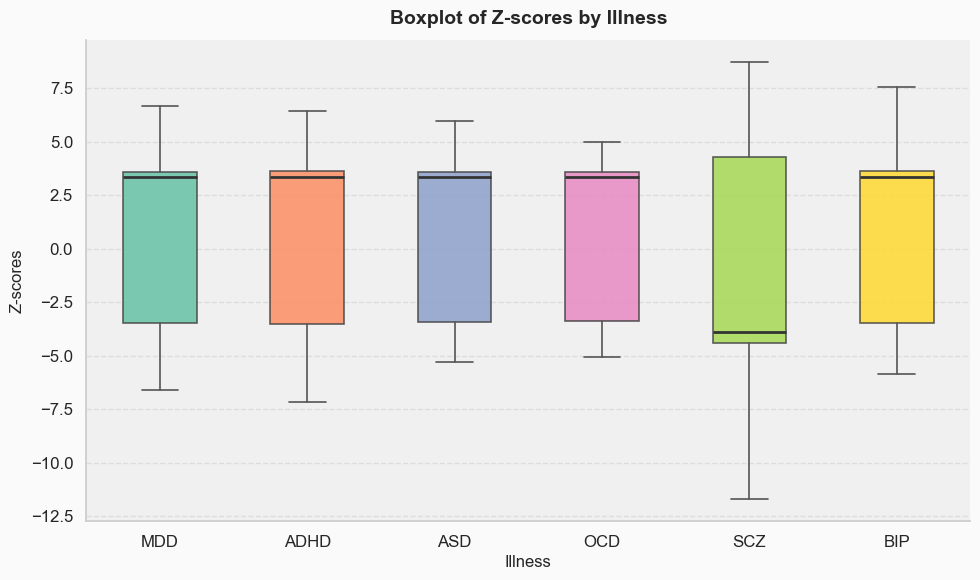

In [16]:
# boxplot of Z_scores for each illness
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [df[df[illness] == 1]["Z_scores"].dropna() for illness in illness_to_ID.keys()]
bp = ax.boxplot(data_to_plot, labels=illness_to_ID.keys(), patch_artist=True,
                boxprops=dict(linewidth=1.2),
                whiskerprops=dict(linewidth=1.2, color="#555555"),
                capprops=dict(linewidth=1.2, color="#555555"),
                medianprops=dict(linewidth=2, color="#333333"),
                flierprops=dict(marker="o", markersize=4, alpha=0.4, markerfacecolor="#999999",
                                markeredgecolor="none"))
for patch, color in zip(bp["boxes"], illness_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor("#444444")

ax.set_facecolor("#f0f0f0")
fig.patch.set_facecolor("#fafafa")
ax.set_title("Boxplot of Z-scores by Illness", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Illness", fontsize=12)
ax.set_ylabel("Z-scores", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()